# TP 03 — Collaborative Filtering

**Recommender Systems — SCIA — Session 03**

Theory reference: `03_CollaborativeFiltering_Theory.ipynb`.

Today you'll implement the collaborative filtering cost function (loop,
then vectorised), train it with a custom gradient descent loop, and
generate recommendations for yourself.

**Required standards:**
- modular code (small, reusable functions)
- numpy-style docstring on every function
- self-contained notebook (no dependency on other notebooks)

In [1]:
import os
import zipfile

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_colwidth", 70)

## 1. Loading the dataset

This session uses a custom, pre-reduced subset of MovieLens (443 users,
4778 movies, focused on titles from 2000 onward) hosted on the course's
MEGA share, together with pre-computed `X`, `W`, `b` used to sanity-check
your cost function against known expected values before training on the
full thing.

Run the cell below once per machine — `megatools` needs to be installed
(`apt install megatools` / `brew install megatools`).

> **Note on the download.** The cell below is the one of the statement, with one addition:
> when `megadl` is not installed (it was not on the machine this notebook was run on), the
> very same archive is fetched through the MEGA API with `curl` and decrypted with `openssl`.
> With `megatools` installed, it runs the original command. The archive is then extracted
> into `./data` by the Python cell that follows instead of `unzip`, which is not installed
> everywhere either. Nothing else than this notebook is needed.

In [2]:
%%bash
set -e
if [ -f "./data/small_movies_Y.csv" ] || [ -f movielens_small.zip ]; then
    echo "Dataset already downloaded, skipping."
    exit 0
fi

if command -v megadl >/dev/null 2>&1; then
    megadl 'https://mega.nz/file/hEJhURAZ#8VeFh14WBrNnMvZxrOfrcXPpHwQDIssXJn8KTYFrPiQ'
else
    # No megatools here. The AES-128-CTR key and nonce are derived from the key
    # that follows the '#' in the link above (first half XOR second half, and
    # the third quarter of the key followed by a zero counter).
    link=$(curl -s --fail -X POST 'https://g.api.mega.co.nz/cs?id=1' \
                -d '[{"a":"g","g":1,"p":"hEJhURAZ"}]' \
           | sed -E 's/.*"g":"([^"]+)".*/\1/; s#\\/#/#g')
    curl -s --fail -o movielens_small.zip.enc "$link"
    openssl enc -d -aes-128-ctr -K 82be9a835d34cda4414dfc3c2d8cd555 \
            -iv 73e91f040322cb170000000000000000 \
            -in movielens_small.zip.enc -out movielens_small.zip
    rm -f movielens_small.zip.enc
fi
echo "movielens_small.zip downloaded."

movielens_small.zip downloaded.


In [3]:
def extract_dataset(archive: str, data_dir: str) -> list[str]:
    """Extract the csv files of the dataset archive, unless they are already there.

    Parameters
    ----------
    archive : str
        Path of ``movielens_small.zip``.
    data_dir : str
        Directory the csv files are extracted into (created if needed).

    Returns
    -------
    list of str
        Names of the csv files present in ``data_dir``.
    """
    if not os.path.exists(os.path.join(data_dir, "small_movies_Y.csv")):
        with zipfile.ZipFile(archive) as zip_file:
            members = [
                name
                for name in zip_file.namelist()
                if name.endswith(".csv") and not name.startswith("__MACOSX")
            ]
            zip_file.extractall(data_dir, members)
    return sorted(name for name in os.listdir(data_dir) if name.endswith(".csv"))


extract_dataset("movielens_small.zip", "./data")

['small_movie_list.csv',
 'small_movies_R.csv',
 'small_movies_W.csv',
 'small_movies_X.csv',
 'small_movies_Y.csv',
 'small_movies_b.csv']

## 2. Loading the matrices

Write the loaders yourself — the expected CSV files are:
`small_movies_X.csv`, `small_movies_W.csv`, `small_movies_b.csv`,
`small_movies_Y.csv`, `small_movies_R.csv`, `small_movie_list.csv`.

In [4]:
def load_precalc_params_small(
    data_dir: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, int, int, int]:
    """Load pre-computed X, W, b for sanity-checking the cost function.

    Parameters
    ----------
    data_dir : str
        Path to the directory containing ``small_movies_X.csv``,
        ``small_movies_W.csv`` and ``small_movies_b.csv``.

    Returns
    -------
    X : numpy.ndarray, shape (n_movies, n_features)
        Pre-computed movie feature vectors.
    W : numpy.ndarray, shape (n_users, n_features)
        Pre-computed user parameter vectors.
    b : numpy.ndarray, shape (1, n_users)
        Pre-computed user bias terms.
    n_movies : int
    n_features : int
    n_users : int
    """
    X = np.loadtxt(os.path.join(data_dir, "small_movies_X.csv"), delimiter=",")
    W = np.loadtxt(os.path.join(data_dir, "small_movies_W.csv"), delimiter=",")
    b = np.loadtxt(os.path.join(data_dir, "small_movies_b.csv"), delimiter=",")
    b = b.reshape(1, -1)
    n_movies, n_features = X.shape
    n_users = W.shape[0]
    return X, W, b, n_movies, n_features, n_users


def load_ratings_small(data_dir: str) -> tuple[np.ndarray, np.ndarray]:
    """Load the pre-built Y and R matrices for the small dataset.

    Parameters
    ----------
    data_dir : str
        Path to the directory containing ``small_movies_Y.csv`` and
        ``small_movies_R.csv``.

    Returns
    -------
    Y : numpy.ndarray, shape (n_movies, n_users)
    R : numpy.ndarray, shape (n_movies, n_users)
    """
    Y = np.loadtxt(os.path.join(data_dir, "small_movies_Y.csv"), delimiter=",")
    R = np.loadtxt(os.path.join(data_dir, "small_movies_R.csv"), delimiter=",")
    return Y, R


def load_movie_list(data_dir: str) -> tuple[list[str], pd.DataFrame]:
    """Load the movie titles, in the same row order as Y/R.

    Parameters
    ----------
    data_dir : str
        Path to the directory containing ``small_movie_list.csv``.

    Returns
    -------
    movie_titles : list of str
        Movie titles, ordered to match the rows of Y/R/X.
    movie_df : pandas.DataFrame
        The full table (title, mean rating, number of ratings, ...).
    """
    movie_df = pd.read_csv(
        os.path.join(data_dir, "small_movie_list.csv"), header=0, index_col=0
    )
    movie_titles = movie_df["title"].to_list()
    return movie_titles, movie_df

In [5]:
data_dir = "./data"
X, W, b, num_movies, num_features, num_users = load_precalc_params_small(data_dir)
Y, R = load_ratings_small(data_dir)

print("Y", Y.shape, "R", R.shape)
print("X", X.shape, "W", W.shape, "b", b.shape)
print("num_features", num_features, "num_movies", num_movies, "num_users", num_users)

Y (4778, 443) R (4778, 443)
X (4778, 10) W (443, 10) b (1, 443)
num_features 10 num_movies 4778 num_users 443


Before writing any model, a quick look at what is actually in `Y` and `R` — the numbers
below explain the `min_ratings` filter used in section 7.

In [6]:
def describe_ratings(Y: np.ndarray, R: np.ndarray) -> pd.Series:
    """Summarise a ratings matrix: size, sparsity and how the ratings are spread.

    Parameters
    ----------
    Y : numpy.ndarray, shape (n_movies, n_users)
        Ratings matrix (0 where unobserved).
    R : numpy.ndarray, shape (n_movies, n_users)
        Indicator matrix.

    Returns
    -------
    pandas.Series
        One labelled statistic per row.
    """
    per_movie = R.sum(axis=1)
    per_user = R.sum(axis=0)
    return pd.Series(
        {
            "movies": Y.shape[0],
            "users": Y.shape[1],
            "observed ratings": int(R.sum()),
            "density of the matrix (%)": round(100 * R.mean(), 2),
            "mean observed rating": round(Y[R == 1].mean(), 3),
            "median ratings per movie": np.median(per_movie),
            "movies with a single rating (%)": round(100 * (per_movie == 1).mean(), 1),
            "movies with >= 20 ratings (%)": round(100 * (per_movie >= 20).mean(), 1),
            "median ratings per user": np.median(per_user),
            "min ratings per user": per_user.min(),
        }
    )


describe_ratings(Y, R).to_frame("value")

,value
movies,4778.000
users,443.000
observed ratings,39253.000
density of the matrix (%),1.850
mean observed rating,3.471
median ratings per movie,2.000
movies with a single rating (%),38.500
movies with >= 20 ratings (%),10.800
median ratings per user,31.000
min ratings per user,1.000


**What to remember from this table.**

* The matrix is **98 % empty** (1.85 % of the cells hold a rating): the `R` mask is not a
  detail, it decides what 98 % of the cost is made of.
* The long tail is severe: half of the movies have **at most 2 ratings**, 38.5 % have a single
  one, and only 10.8 % reach 20 ratings. The mean of such a movie is not an estimate of
  anything — this is why `top_recommendations` has a `min_ratings` argument (section 7).
* Users are unequal too: the median user rated 31 movies, the least active one a single movie.

## 3. Exercise 1 — the cost function (loop implementation)

Implement `cofi_cost_func` using explicit `for` loops over users and
movies. Only accumulate the squared error where `R[i, j] == 1`.

In [7]:
def cofi_cost_func(
    X: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Y: np.ndarray,
    R: np.ndarray,
    lambda_: float,
) -> float:
    """Compute the collaborative filtering cost, using explicit loops.

    Parameters
    ----------
    X : numpy.ndarray, shape (n_movies, n_features)
        Movie feature vectors.
    W : numpy.ndarray, shape (n_users, n_features)
        User parameter vectors.
    b : numpy.ndarray, shape (1, n_users)
        User bias terms.
    Y : numpy.ndarray, shape (n_movies, n_users)
        Observed ratings (0 where unobserved).
    R : numpy.ndarray, shape (n_movies, n_users)
        Indicator matrix: 1 where Y holds a real, observed rating.
    lambda_ : float
        Regularisation strength.

    Returns
    -------
    float
        The cost J(X, W, b) as defined in the theory notebook.
    """
    n_movies, n_users = Y.shape
    squared_error = 0.0
    for j in range(n_users):
        w_j = W[j, :]
        b_j = b[0, j]
        for i in range(n_movies):
            if R[i, j] == 1:
                error = np.dot(w_j, X[i, :]) + b_j - Y[i, j]
                squared_error += error**2
    regularisation = np.sum(W**2) + np.sum(X**2)
    return float(0.5 * squared_error + 0.5 * lambda_ * regularisation)

Test on a small slice of the real, pre-computed parameters — with known
expected values, so a mismatch tells you exactly where to look.

In [8]:
n_users_r, n_movies_r, n_features_r = 4, 5, 3
X_r = X[:n_movies_r, :n_features_r]
W_r = W[:n_users_r, :n_features_r]
b_r = b[0, :n_users_r].reshape(1, -1)
Y_r = Y[:n_movies_r, :n_users_r]
R_r = R[:n_movies_r, :n_users_r]

cost_no_reg = cofi_cost_func(X_r, W_r, b_r, Y_r, R_r, lambda_=0)
print(f"Cost (no regularisation): {cost_no_reg:0.2f}   (expected: 13.67)")

cost_with_reg = cofi_cost_func(X_r, W_r, b_r, Y_r, R_r, lambda_=1.5)
print(f"Cost (with regularisation): {cost_with_reg:0.2f}   (expected: 28.09)")

Cost (no regularisation): 13.67   (expected: 13.67)
Cost (with regularisation): 28.09   (expected: 28.09)


## 4. Exercise 2 — the cost function (vectorised implementation)

Loops don't scale: the cost is recomputed at every training step, on the
full matrix. Implement a vectorised version using `tf.linalg.matmul`
instead.

**Watch out**: apply the `R` mask *before* squaring the error, or you'll
silently include every unobserved rating as if it were a real "0★" rating.

In [9]:
def cofi_cost_func_vectorized(X, W, b, Y, R, lambda_: float):
    """Compute the collaborative filtering cost, vectorised.

    Parameters
    ----------
    X : array-like, shape (n_movies, n_features)
        Movie feature vectors (TensorFlow tensor or numpy array).
    W : array-like, shape (n_users, n_features)
        User parameter vectors.
    b : array-like, shape (1, n_users)
        User bias terms.
    Y : array-like, shape (n_movies, n_users)
        Observed ratings (0 where unobserved).
    R : array-like, shape (n_movies, n_users)
        Indicator matrix: 1 where Y holds a real, observed rating.
    lambda_ : float
        Regularisation strength.

    Returns
    -------
    float or tf.Tensor
        The cost J(X, W, b), numerically identical to `cofi_cost_func`
        given the same inputs.
    """
    # The mask is applied to the error itself, hence before the square.
    error = (tf.linalg.matmul(X, tf.transpose(W)) + b - Y) * R
    regularisation = tf.reduce_sum(X**2) + tf.reduce_sum(W**2)
    return 0.5 * tf.reduce_sum(error**2) + 0.5 * lambda_ * regularisation

In [10]:
cost_no_reg_v = cofi_cost_func_vectorized(X_r, W_r, b_r, Y_r, R_r, lambda_=0)
cost_with_reg_v = cofi_cost_func_vectorized(X_r, W_r, b_r, Y_r, R_r, lambda_=1.5)
print(f"Cost (no regularisation): {float(cost_no_reg_v):0.2f}   (expected: 13.67)")
print(f"Cost (with regularisation): {float(cost_with_reg_v):0.2f}   (expected: 28.09)")

assert np.isclose(
    float(cost_no_reg_v), cost_no_reg, atol=1e-6
), "Vectorised and loop implementations disagree (no regularisation) — check the R mask."
assert np.isclose(
    float(cost_with_reg_v), cost_with_reg, atol=1e-6
), "Vectorised and loop implementations disagree (with regularisation)."
print("Vectorised implementation matches the loop version.")

Cost (no regularisation): 13.67   (expected: 13.67)
Cost (with regularisation): 28.09   (expected: 28.09)
Vectorised implementation matches the loop version.


Two extra checks that the statement only hints at: what the *wrong* formula (mask forgotten)
would have returned on the same slice, and how much the vectorisation actually buys on the
full matrix.

In [11]:
import time


def cofi_cost_without_mask(X, W, b, Y, lambda_: float):
    """Compute the cost with the R mask forgotten (the bug the statement warns about).

    Parameters
    ----------
    X, W, b, Y : array-like
        Same as in `cofi_cost_func_vectorized`.
    lambda_ : float
        Regularisation strength.

    Returns
    -------
    tf.Tensor
        A cost in which every unobserved rating counts as a real rating of 0.
    """
    error = tf.linalg.matmul(X, tf.transpose(W)) + b - Y
    regularisation = tf.reduce_sum(X**2) + tf.reduce_sum(W**2)
    return 0.5 * tf.reduce_sum(error**2) + 0.5 * lambda_ * regularisation


def time_call(function, *args, repeat: int = 1) -> float:
    """Return the best wall-clock time of ``function(*args)`` over a few runs.

    Parameters
    ----------
    function : callable
        Function to time.
    *args
        Positional arguments passed to the function.
    repeat : int, optional
        Number of runs; the fastest one is kept (default 1).

    Returns
    -------
    float
        Best duration, in seconds.
    """
    durations = []
    for _ in range(repeat):
        start = time.perf_counter()
        function(*args)
        durations.append(time.perf_counter() - start)
    return min(durations)


print(f"Slice, mask forgotten : {float(cofi_cost_without_mask(X_r, W_r, b_r, Y_r, 0)):0.2f}"
      f"   (correct value: {cost_no_reg:0.2f})")

loop_seconds = time_call(cofi_cost_func, X, W, b, Y, R, 1.5)
vectorised_seconds = time_call(cofi_cost_func_vectorized, X, W, b, Y, R, 1.5, repeat=5)
print(f"Full matrix, loops      : {loop_seconds:6.2f} s")
print(f"Full matrix, vectorised : {vectorised_seconds:6.4f} s   "
      f"(x{loop_seconds / vectorised_seconds:,.0f} faster)")
print(f"Same value on the full matrix: "
      f"{np.isclose(cofi_cost_func(X, W, b, Y, R, 1.5), float(cofi_cost_func_vectorized(X, W, b, Y, R, 1.5)))}")

Slice, mask forgotten : 18.45   (correct value: 13.67)


Full matrix, loops      :   0.28 s
Full matrix, vectorised : 0.0254 s   (x11 faster)


Same value on the full matrix: True


**Reading these numbers.**

* Both implementations return the expected 13.67 and 28.09, and they still agree on the full
  4778 × 443 matrix.
* Forgetting the mask turns 13.67 into 18.45 on a slice where only a few cells are
  unobserved. On the full matrix 98 % of the cells are unobserved: without the mask the
  model would spend nearly all its capacity learning to predict "0★" everywhere.
* The speed-up measured here is about one order of magnitude — less than one might expect,
  because the loop skips the 98 % of unobserved cells with a cheap test. The real reason to
  vectorise is elsewhere: the vectorised cost is made of TensorFlow operations only, so
  `tf.GradientTape` can differentiate it, and the training below evaluates it 200 times.

## 5. Rating some movies yourself

Look up a few movies you recognise in `small_movie_list.csv`, then rate
them. `my_ratings` is indexed by row position in `Y`/`movie_titles` — not
by an external movieId.

In [12]:
def normalize_ratings(Y: np.ndarray, R: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Subtract each movie's mean observed rating (mean-centre by row).

    Parameters
    ----------
    Y : numpy.ndarray, shape (n_movies, n_users)
        Ratings matrix.
    R : numpy.ndarray, shape (n_movies, n_users)
        Indicator matrix.

    Returns
    -------
    Y_norm : numpy.ndarray, shape (n_movies, n_users)
        Y with each row's mean (computed over observed entries only)
        subtracted.
    Y_mean : numpy.ndarray, shape (n_movies, 1)
        The per-movie mean that was subtracted (needed later to restore
        the original rating scale).
    """
    # The epsilon keeps a movie without any rating at a mean of 0 instead of NaN.
    Y_mean = (np.sum(Y * R, axis=1) / (np.sum(R, axis=1) + 1e-12)).reshape(-1, 1)
    # Only the observed entries are shifted: the unobserved ones stay at 0.
    Y_norm = Y - Y_mean * R
    return Y_norm, Y_mean

In [13]:
movie_titles, movie_df = load_movie_list(data_dir)

# Find a few titles you recognise, note their row index, then rate them below.
[title for title in movie_titles if "Toy Story" in title]

['Toy Story 3 (2010)']

Row indices are easy to get wrong by one, so the ratings below are written **by title** and
resolved to row positions by a small helper that fails loudly on a title that is not in the
list. `my_ratings` itself stays indexed by row position, as the statement requires.

In [14]:
def find_movies(query: str, movie_df: pd.DataFrame) -> pd.DataFrame:
    """List the movies whose title contains ``query`` (case-insensitive).

    Parameters
    ----------
    query : str
        Substring to look for in the titles.
    movie_df : pandas.DataFrame
        Movie table, with a ``title`` column, in the row order of Y.

    Returns
    -------
    pandas.DataFrame
        The matching rows; the index is the row position in Y.
    """
    mask = movie_df["title"].str.contains(query, case=False, regex=False)
    return movie_df.loc[mask, ["title", "mean rating", "number of ratings"]]


def build_my_ratings(ratings_by_title: dict[str, float], movie_titles: list[str]) -> np.ndarray:
    """Turn a ``{title: rating}`` dictionary into a ratings vector aligned with Y.

    Parameters
    ----------
    ratings_by_title : dict of str to float
        Ratings (0.5 to 5.0) keyed by the exact movie title.
    movie_titles : list of str
        Movie titles, in the row order of Y.

    Returns
    -------
    numpy.ndarray, shape (n_movies,)
        The ratings, 0 for every movie that was not rated.

    Raises
    ------
    KeyError
        If a title is not in ``movie_titles``.
    ValueError
        If a rating is outside [0.5, 5].
    """
    row_of_title = {title: row for row, title in enumerate(movie_titles)}
    ratings = np.zeros(len(movie_titles))
    for title, rating in ratings_by_title.items():
        if title not in row_of_title:
            raise KeyError(f"Unknown movie title: {title!r}")
        if not 0.5 <= rating <= 5:
            raise ValueError(f"Rating out of range for {title!r}: {rating}")
        ratings[row_of_title[title]] = rating
    return ratings


find_movies("lord of the rings", movie_df)

,title,mean rating,number of ratings
393,"Lord of the Rings: The Fellowship of the Ring, The (2001)",4.106061,198
653,"Lord of the Rings: The Two Towers, The (2002)",4.021277,188
929,"Lord of the Rings: The Return of the King, The (2003)",4.118919,185


In [15]:
MY_RATINGS_BY_TITLE = {
    # What I like: epic fantasy, Nolan, twisty thrillers, a bit of animation.
    "Lord of the Rings: The Fellowship of the Ring, The (2001)": 5.0,
    "Lord of the Rings: The Return of the King, The (2003)": 5.0,
    "Dark Knight, The (2008)": 5.0,
    "Inception (2010)": 5.0,
    "Interstellar (2014)": 4.5,
    "Memento (2000)": 4.5,
    "Prestige, The (2006)": 4.5,
    "Spirited Away (Sen to Chihiro no kamikakushi) (2001)": 4.5,
    "WALL·E (2008)": 4.0,
    "Gladiator (2000)": 4.0,
    # Fine, nothing more.
    "Shrek (2001)": 3.5,
    "Avatar (2009)": 3.0,
    "Hangover, The (2009)": 2.5,
    # What I do not like: lazy sequels, broad comedies, teen romance.
    "Matrix Revolutions, The (2003)": 2.0,
    "Star Wars: Episode II - Attack of the Clones (2002)": 2.0,
    "Meet the Parents (2000)": 2.0,
    "Transformers: Revenge of the Fallen (2009)": 1.5,
    "Mission: Impossible II (2000)": 1.5,
    "Scary Movie 2 (2001)": 1.0,
    "Twilight (2008)": 1.0,
}

my_ratings = build_my_ratings(MY_RATINGS_BY_TITLE, movie_titles)

my_rated = [i for i in range(len(my_ratings)) if my_ratings[i] > 0]
for i in my_rated:
    print(f"Rated {my_ratings[i]} for {movie_titles[i]}")

Rated 4.0 for Gladiator (2000)
Rated 1.5 for Mission: Impossible II (2000)
Rated 2.0 for Meet the Parents (2000)
Rated 4.5 for Memento (2000)
Rated 3.5 for Shrek (2001)
Rated 1.0 for Scary Movie 2 (2001)
Rated 5.0 for Lord of the Rings: The Fellowship of the Ring, The (2001)
Rated 2.0 for Star Wars: Episode II - Attack of the Clones (2002)
Rated 4.5 for Spirited Away (Sen to Chihiro no kamikakushi) (2001)
Rated 2.0 for Matrix Revolutions, The (2003)
Rated 5.0 for Lord of the Rings: The Return of the King, The (2003)
Rated 4.5 for Prestige, The (2006)
Rated 5.0 for Dark Knight, The (2008)
Rated 4.0 for WALL·E (2008)
Rated 1.0 for Twilight (2008)
Rated 2.5 for Hangover, The (2009)
Rated 1.5 for Transformers: Revenge of the Fallen (2009)
Rated 3.0 for Avatar (2009)
Rated 5.0 for Inception (2010)
Rated 4.5 for Interstellar (2014)


In [16]:
# Fold your ratings in as an extra column, then normalise.
Y_ext = np.c_[my_ratings, Y]
R_ext = np.c_[(my_ratings != 0).astype(int), R]
Y_norm, Y_mean = normalize_ratings(Y_ext, R_ext)
print("Y_ext", Y_ext.shape)

Y_ext (4778, 444)


**Why mean-normalise?** With the mean of each movie removed, a user for whom the model knows
nothing (a vector `w` shrunk to 0 by the regularisation) is predicted the *average* rating of
every movie instead of 0★. It also makes the optimisation easier: the model only has to learn
the *deviations* from the average, which are small and centred.

## 6. Training

Initialise `X`, `W`, `b` randomly as `tf.Variable`s, then run the custom
`GradientTape` training loop from the theory notebook.

The training loop of the statement is wrapped into a function, with exactly the same
initialisation (same seed, same order of the random draws), optimiser and number of steps: it
is reused as is in the regularisation study of section 9.

In [17]:
def train_cofi(
    Y_norm: np.ndarray,
    R: np.ndarray,
    n_features: int = 100,
    lambda_: float = 1.0,
    iterations: int = 200,
    learning_rate: float = 0.1,
    seed: int = 1234,
    verbose_every: int = 20,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[float]]:
    """Learn X, W and b with a custom GradientTape loop (Adam).

    Parameters
    ----------
    Y_norm : numpy.ndarray, shape (n_movies, n_users)
        Mean-normalised ratings.
    R : numpy.ndarray, shape (n_movies, n_users)
        Indicator matrix of the ratings used for training.
    n_features : int, optional
        Number of latent features (default 100).
    lambda_ : float, optional
        Regularisation strength (default 1.0).
    iterations : int, optional
        Number of gradient steps (default 200).
    learning_rate : float, optional
        Learning rate of Adam (default 0.1).
    seed : int, optional
        Seed of the random initialisation (default 1234).
    verbose_every : int, optional
        Print the cost every this many steps; 0 disables printing (default 20).

    Returns
    -------
    X : numpy.ndarray, shape (n_movies, n_features)
        Learned movie feature vectors.
    W : numpy.ndarray, shape (n_users, n_features)
        Learned user parameter vectors.
    b : numpy.ndarray, shape (1, n_users)
        Learned user biases.
    history : list of float
        Cost at every step.
    """
    n_movies, n_users = Y_norm.shape
    tf.random.set_seed(seed)
    X_var = tf.Variable(tf.random.normal((n_movies, n_features), dtype=tf.float64), name="X")
    W_var = tf.Variable(tf.random.normal((n_users, n_features), dtype=tf.float64), name="W")
    b_var = tf.Variable(tf.random.normal((1, n_users), dtype=tf.float64), name="b")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    history = []
    for step in range(iterations):
        with tf.GradientTape() as tape:
            cost = cofi_cost_func_vectorized(X_var, W_var, b_var, Y_norm, R, lambda_)
        grads = tape.gradient(cost, [X_var, W_var, b_var])
        optimizer.apply_gradients(zip(grads, [X_var, W_var, b_var]))
        history.append(float(cost))
        if verbose_every and step % verbose_every == 0:
            print(f"iteration {step:>4}: cost = {float(cost):.1f}")
    return X_var.numpy(), W_var.numpy(), b_var.numpy(), history

In [18]:
num_movies_ext, num_users_ext = Y_ext.shape
n_features_train = 100
lambda_ = 1.0
iterations = 200

X_learned, W_learned, b_learned, cost_history = train_cofi(
    Y_norm, R_ext, n_features=n_features_train, lambda_=lambda_, iterations=iterations
)
print(f"final cost after {iterations} iterations: {cost_history[-1]:.1f}")

iteration    0: cost = 2287168.5


iteration   20: cost = 133669.7


iteration   40: cost = 50547.1


iteration   60: cost = 23859.1


iteration   80: cost = 13180.3


...

iteration  120: cost = 5616.3


iteration  140: cost = 4174.1


iteration  160: cost = 3331.9


iteration  180: cost = 2822.4


final cost after 200 iterations: 2517.0


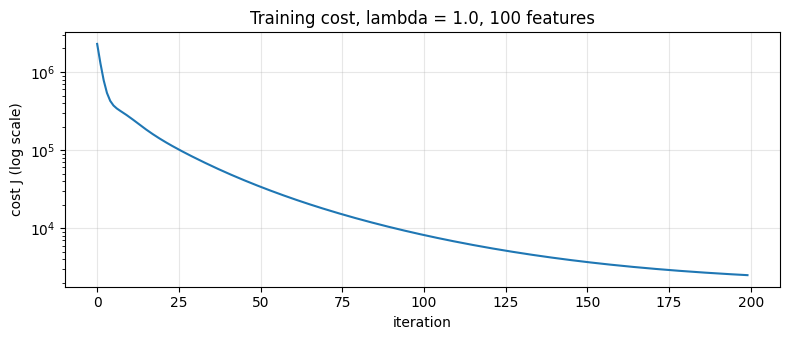

In [19]:
def plot_cost_history(history: list[float], title: str) -> None:
    """Plot the training cost against the iteration number (log scale).

    Parameters
    ----------
    history : list of float
        Cost at every training step.
    title : str
        Title of the figure.
    """
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(history)
    ax.set(yscale="log", xlabel="iteration", ylabel="cost J (log scale)", title=title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_cost_history(cost_history, f"Training cost, lambda = {lambda_}, {n_features_train} features")

The cost falls from 2.3 million to about 2 500, by three orders of magnitude. Two remarks:

* it is **still decreasing** when the loop stops (2 822 → 2 517 over the last 20 steps): 200
  iterations do not reach convergence, which acts as an implicit early stopping;
* this number mixes the squared error and the regularisation term, and it is measured on the
  ratings the model was trained on. A low value says the optimiser works, not that the
  recommendations are good — section 9 measures that properly.

## 7. Recommendations

Predict every rating for your new-user column (column 0), restore the mean
that was subtracted in step 5, and rank the movies you haven't already
rated.

In [20]:
def predict_ratings(
    X: np.ndarray, W: np.ndarray, b: np.ndarray, Y_mean: np.ndarray
) -> np.ndarray:
    """Predict every rating, back on the original rating scale.

    Parameters
    ----------
    X, W, b : numpy.ndarray
        Learned parameters.
    Y_mean : numpy.ndarray, shape (n_movies, 1)
        Per-movie mean subtracted during normalisation, added back here.

    Returns
    -------
    numpy.ndarray, shape (n_movies, n_users)
        Predicted ratings.
    """
    return X @ W.T + b + Y_mean


def top_recommendations(
    X: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Y_mean: np.ndarray,
    movie_titles: list[str],
    movie_df: pd.DataFrame,
    my_rated: list[int],
    min_ratings: int = 20,
    n: int = 10,
) -> pd.DataFrame:
    """Rank the top-N recommended movies for the new user (column 0).

    Parameters
    ----------
    X, W, b : numpy.ndarray
        Learned parameters (call ``.numpy()`` on the tf.Variables first).
    Y_mean : numpy.ndarray, shape (n_movies, 1)
        Per-movie mean subtracted during normalisation, to be added back.
    movie_titles : list of str
        Movie title for each row, in order.
    movie_df : pandas.DataFrame
        Must contain a ``number of ratings`` column, aligned by row order
        with movie_titles, used for the min_ratings filter.
    my_rated : list of int
        Row indices already rated by this user; excluded from the results.
    min_ratings : int, optional
        Minimum number of ratings (across all users) a movie must have to
        be eligible (default 20).
    n : int, optional
        Number of recommendations to return (default 10).

    Returns
    -------
    pandas.DataFrame
        Columns: ``title``, ``predicted_rating``, ``number of ratings``,
        sorted descending by predicted rating, top ``n`` rows.
    """
    my_predictions = predict_ratings(X, W, b, Y_mean)[:, 0]
    candidates = pd.DataFrame(
        {
            "title": movie_titles,
            "predicted_rating": my_predictions,
            "number of ratings": movie_df["number of ratings"].to_numpy(),
        }
    )
    eligible = candidates["number of ratings"] >= min_ratings
    eligible &= ~candidates.index.isin(my_rated)
    return (
        candidates[eligible]
        .sort_values("predicted_rating", ascending=False)
        .head(n)
    )

In [21]:
recommendations = top_recommendations(
    X_learned,
    W_learned,
    b_learned,
    Y_mean,
    movie_titles=movie_titles,
    movie_df=movie_df,
    my_rated=my_rated,
    min_ratings=20,
    n=10,
)
recommendations

,title,predicted_rating,number of ratings
653,"Lord of the Rings: The Two Towers, The (2002)",4.691325,188
3014,"Avengers, The (2012)",4.207074,69
3083,"Dark Knight Rises, The (2012)",4.138326,76
3714,Guardians of the Galaxy (2014),4.108645,59
4553,Logan (2017),4.103386,25
395,"Beautiful Mind, A (2001)",4.027038,123
2395,Inglourious Basterds (2009),4.018694,88
5,"Boondock Saints, The (2000)",4.015137,43
2804,Harry Potter and the Deathly Hallows: Part 1 (2010),3.935014,47
174,Traffic (2000),3.934313,70


Two sanity checks on this list: how well the model reproduces the ratings I actually gave
(it has seen them, so this only tells whether the training fitted them), and what the list
looks like when the `min_ratings` filter is switched off.

In [22]:
def compare_with_my_ratings(
    X: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Y_mean: np.ndarray,
    my_ratings: np.ndarray,
    movie_titles: list[str],
) -> pd.DataFrame:
    """Put the ratings of the new user (column 0) next to the model's predictions.

    Parameters
    ----------
    X, W, b : numpy.ndarray
        Learned parameters.
    Y_mean : numpy.ndarray, shape (n_movies, 1)
        Per-movie mean subtracted during normalisation.
    my_ratings : numpy.ndarray, shape (n_movies,)
        Ratings of the new user, 0 where unrated.
    movie_titles : list of str
        Movie title for each row.

    Returns
    -------
    pandas.DataFrame
        One row per rated movie: the rating, the prediction and the movie mean.
    """
    rated = np.flatnonzero(my_ratings)
    predictions = predict_ratings(X, W, b, Y_mean)[:, 0]
    return pd.DataFrame(
        {
            "title": [movie_titles[i] for i in rated],
            "my_rating": my_ratings[rated],
            "predicted_rating": predictions[rated].round(2),
            "movie_mean": Y_mean[rated, 0].round(2),
        }
    ).sort_values(["my_rating", "title"], ascending=[False, True])


fit_on_my_ratings = compare_with_my_ratings(
    X_learned, W_learned, b_learned, Y_mean, my_ratings, movie_titles
)
print("mean absolute error on my own ratings: "
      f"{(fit_on_my_ratings.my_rating - fit_on_my_ratings.predicted_rating).abs().mean():.2f}")
fit_on_my_ratings

mean absolute error on my own ratings: 0.09


,title,my_rating,predicted_rating,movie_mean
12,"Dark Knight, The (2008)",5.0,4.93,4.24
18,Inception (2010),5.0,4.87,4.07
6,"Lord of the Rings: The Fellowship of the Ring, The (2001)",5.0,4.90,4.11
10,"Lord of the Rings: The Return of the King, The (2003)",5.0,4.90,4.12
19,Interstellar (2014),4.5,4.40,4.00
3,Memento (2000),4.5,4.45,4.12
11,"Prestige, The (2006)",4.5,4.33,4.01
8,Spirited Away (Sen to Chihiro no kamikakushi) (2001),4.5,4.47,4.16
0,Gladiator (2000),4.0,3.97,3.94
13,WALL·E (2008),4.0,3.94,4.06


In [23]:
top_recommendations(
    X_learned, W_learned, b_learned, Y_mean,
    movie_titles=movie_titles, movie_df=movie_df, my_rated=my_rated,
    min_ratings=0, n=10,
)

,title,predicted_rating,number of ratings
653,"Lord of the Rings: The Two Towers, The (2002)",4.691325,188
3623,"Garden of Words, The (Koto no ha no niwa) (2013)",4.544204,1
3249,"Odd Life of Timothy Green, The (2012)",4.528186,1
4491,The Girl with All the Gifts (2016),4.515328,1
570,"Son of the Bride (Hijo de la novia, El) (2001)",4.506215,1
4200,Deathgasm (2015),4.504554,1
2456,Eichmann (2007),4.490692,1
1225,Battle Royale 2: Requiem (Batoru rowaiaru II: Chinkonka) (2003),4.490600,1
2925,Louis Theroux: Law & Disorder (2008),4.490401,1
3062,Into the Abyss (2011),4.489899,1


**Is the list any good?**

* It is coherent with what I rated: the first recommendation is *The Two Towers* — the one
  episode of the trilogy I left out on purpose — followed by *The Dark Knight Rises* and a
  group of well-liked blockbusters (*Avengers*, *Guardians of the Galaxy*, *Logan*). Nothing
  resembling the comedies and teen romances I rated low.
* The model reproduces my own 20 ratings almost exactly (mean absolute error 0.09, where
  the movie means are off by about 0.8). With 100 features to explain 20 ratings this is
  memorisation, not evidence of quality.
* Without the `min_ratings` filter, 9 of the 10 recommendations are movies with **a single
  rating**: their "mean" is the 5★ one person gave, and the model has nothing to correct it
  with. The filter is what makes the list usable.

## 8. Comparison table

Log this session's model into the running comparison table from Session 01.

In [24]:
def log_result(
    comparison_path: str,
    model_name: str,
    metric_name: str,
    metric_value: float,
    session: str = "S03",
) -> pd.DataFrame:
    """Append a row to the running model-comparison table, creating it if needed.

    Parameters
    ----------
    comparison_path : str
        CSV path of the running comparison table.
    model_name : str
        Name of the model being logged.
    metric_name : str
        Name of the metric column.
    metric_value : float
        Value of the metric for this model.
    session : str, optional
        Session label written in the ``session`` column (default "S03").

    Returns
    -------
    pandas.DataFrame
        The updated comparison table.

    Notes
    -----
    A model already logged for the same session keeps its row and only gets
    the metric column updated, so that re-running the notebook does not pile
    up duplicated rows. An existing table without the ``session`` or the
    ``model`` column is accepted: the missing columns are added.
    """
    table = pd.read_csv(comparison_path) if os.path.exists(comparison_path) else pd.DataFrame()
    # A table started in another session may not have these two columns yet.
    for column in ("session", "model"):
        if column not in table.columns:
            table[column] = pd.Series(dtype=object)
    same_model = (table["session"] == session) & (table["model"] == model_name)
    if same_model.any():
        table.loc[same_model, metric_name] = metric_value
    else:
        new_row = pd.DataFrame(
            [{"session": session, "model": model_name, metric_name: metric_value}]
        )
        table = new_row if table.empty else pd.concat([table, new_row], ignore_index=True)
    table.to_csv(comparison_path, index=False)
    return table


log_result(
    comparison_path="./comparison_table.csv",
    model_name="Collaborative filtering (MF)",
    metric_name="mean_predicted_top10",
    metric_value=recommendations["predicted_rating"].mean(),
)

,session,model,mean_predicted_top10
0,S03,Collaborative filtering (MF),4.117895


`comparison_table.csv` is written next to the notebook, with the `session` / `model` columns
that Session 04's `log_results` also uses, so the two tables can simply be concatenated.

A caveat on the metric asked here: `mean_predicted_top10` is **not a quality measure**. It is
the model's own opinion of its recommendations, and a model can inflate it at will — the
unregularised model of the next section "predicts" 23.9★ on average for its top 10. A
validation RMSE is therefore added to the same table at the end of section 9.

## 9. Going further (open-ended)

Pick at least one:

**Regularisation.** Retrain with three different values of `lambda_`
(e.g. 0, 1, 10). How do the recommendations change? Which value seems to
give the best balance between overfitting and underfitting, and how did
you judge that?

**Cold start.** Propose a strategy for recommending to a user with zero
ratings, or a movie nobody has rated yet. Prototype it — even a simple
heuristic counts — and discuss where it breaks down.

**Toward a hybrid.** Sketch (in words, or a few lines of code) how you'd
combine this model with Session 02's content-based filter. What would each
contribute? We'll build this properly in Session 05.

The topic picked here is the **regularisation**.

Looking at the recommendation lists alone cannot tell overfitting from underfitting, so some
ground truth is needed: **10 % of the observed ratings are hidden** (never my own, so that the
lists stay comparable), the model is trained on the remaining 90 % and the error is measured
on the hidden ones. The mean of each movie is recomputed on the training ratings only —
otherwise the hidden ratings would leak into the predictions through `Y_mean`.

In [25]:
def split_observed_ratings(
    R: np.ndarray, validation_fraction: float = 0.1, seed: int = 0, keep_columns: tuple = (0,)
) -> tuple[np.ndarray, np.ndarray]:
    """Split the observed ratings into a training mask and a validation mask.

    Parameters
    ----------
    R : numpy.ndarray, shape (n_movies, n_users)
        Indicator matrix of all the observed ratings.
    validation_fraction : float, optional
        Share of the observed ratings sent to validation (default 0.1).
    seed : int, optional
        Seed of the random draw (default 0).
    keep_columns : tuple of int, optional
        Users whose ratings all stay in the training set (default: column 0,
        the new user).

    Returns
    -------
    R_train : numpy.ndarray, shape (n_movies, n_users)
    R_validation : numpy.ndarray, shape (n_movies, n_users)
        Two disjoint masks whose sum is R.
    """
    rng = np.random.default_rng(seed)
    hidden = (rng.random(R.shape) < validation_fraction) & (R == 1)
    hidden[:, list(keep_columns)] = False
    R_validation = hidden.astype(R.dtype)
    return R - R_validation, R_validation


def rmse(predictions: np.ndarray, Y: np.ndarray, R: np.ndarray) -> float:
    """Root mean squared error over the entries selected by a mask.

    Parameters
    ----------
    predictions : numpy.ndarray, shape (n_movies, n_users)
        Predicted ratings.
    Y : numpy.ndarray, shape (n_movies, n_users)
        True ratings.
    R : numpy.ndarray, shape (n_movies, n_users)
        Mask of the entries to score.

    Returns
    -------
    float
        The RMSE on the masked entries.
    """
    return float(np.sqrt(np.sum(R * (predictions - Y) ** 2) / np.sum(R)))


R_train, R_validation = split_observed_ratings(R_ext, validation_fraction=0.1, seed=0)
Y_norm_train, Y_mean_train = normalize_ratings(Y_ext * R_train, R_train)

# Hidden ratings of movies left without any training rating cannot be predicted by a
# collaborative model: they are scored apart.
warm_movies = (R_train.sum(axis=1) > 0).reshape(-1, 1)
R_validation_warm = R_validation * warm_movies

print(f"training ratings   : {int(R_train.sum()):,}")
print(f"validation ratings : {int(R_validation.sum()):,} "
      f"(of which {int(R_validation.sum() - R_validation_warm.sum()):,} on movies "
      "with no training rating left)")

movie_mean_rmse = rmse(np.broadcast_to(Y_mean_train, Y_ext.shape), Y_ext, R_validation_warm)
print(f"baseline, movie mean only — validation RMSE: {movie_mean_rmse:.3f}")

training ratings   : 35,362
validation ratings : 3,911 (of which 198 on movies with no training rating left)
baseline, movie mean only — validation RMSE: 0.971


In [26]:
def regularisation_study(
    lambdas: list[float],
    Y: np.ndarray,
    R_train: np.ndarray,
    R_validation: np.ndarray,
    movie_titles: list[str],
    movie_df: pd.DataFrame,
    my_rated: list[int],
    **train_kwargs,
) -> tuple[pd.DataFrame, dict[float, pd.DataFrame]]:
    """Train one model per value of lambda and collect errors and recommendations.

    Parameters
    ----------
    lambdas : list of float
        Regularisation strengths to compare.
    Y : numpy.ndarray, shape (n_movies, n_users)
        Ratings matrix (new user in column 0).
    R_train, R_validation : numpy.ndarray, shape (n_movies, n_users)
        Masks of the training and of the validation ratings.
    movie_titles : list of str
        Movie title for each row.
    movie_df : pandas.DataFrame
        Movie table with the ``number of ratings`` column.
    my_rated : list of int
        Rows already rated by the new user.
    **train_kwargs
        Extra arguments forwarded to `train_cofi`.

    Returns
    -------
    summary : pandas.DataFrame
        One row per lambda: training and validation RMSE, size of the learned
        vectors, spread of the predictions for the new user.
    top10 : dict of float to pandas.DataFrame
        The top-10 list of the new user for each lambda.
    """
    Y_norm_train, Y_mean_train = normalize_ratings(Y * R_train, R_train)
    rows, top10 = [], {}
    for lambda_ in lambdas:
        X, W, b, _ = train_cofi(
            Y_norm_train, R_train, lambda_=lambda_, verbose_every=0, **train_kwargs
        )
        predictions = predict_ratings(X, W, b, Y_mean_train)
        top10[lambda_] = top_recommendations(
            X, W, b, Y_mean_train, movie_titles, movie_df, my_rated, min_ratings=20, n=10
        )
        rows.append(
            {
                "lambda": lambda_,
                "train_rmse": rmse(predictions, Y, R_train),
                "validation_rmse": rmse(predictions, Y, R_validation),
                "validation_rmse_clipped": rmse(np.clip(predictions, 0.5, 5), Y, R_validation),
                "mean |x|": np.linalg.norm(X, axis=1).mean(),
                "mean |w|": np.linalg.norm(W, axis=1).mean(),
                "my predictions: min": predictions[:, 0].min(),
                "my predictions: max": predictions[:, 0].max(),
                "top10 mean prediction": top10[lambda_]["predicted_rating"].mean(),
            }
        )
    return pd.DataFrame(rows).set_index("lambda"), top10


LAMBDAS = [0.0, 1.0, 10.0, 30.0]
study, top10_by_lambda = regularisation_study(
    LAMBDAS, Y_ext, R_train, R_validation_warm, movie_titles, movie_df, my_rated,
    n_features=n_features_train, iterations=iterations,
)
study.round(3)

,train_rmse,validation_rmse,validation_rmse_clipped,mean |x|,mean |w|,my predictions: min,my predictions: max,top10 mean prediction
lambda,,,,,,,,
0.0,0.024,3.904,1.916,10.253,7.426,-39.329,42.749,23.889
1.0,0.084,0.970,0.961,0.442,1.784,-0.460,4.950,4.165
10.0,0.565,0.854,0.853,0.162,0.565,-0.310,4.699,3.991
30.0,0.747,0.867,0.866,0.011,0.022,-0.281,4.719,3.920


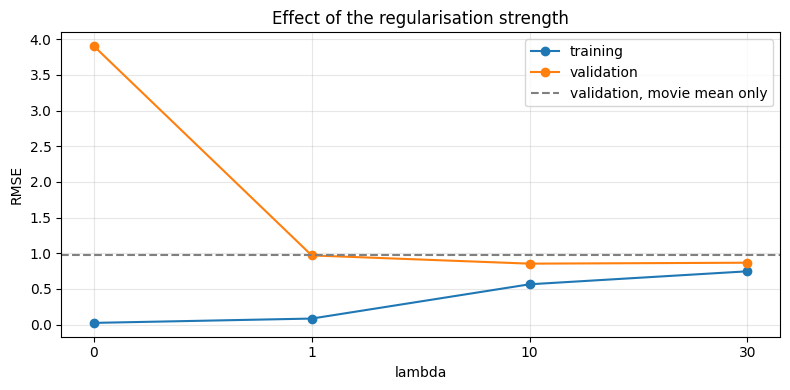

In [27]:
def plot_regularisation(study: pd.DataFrame, baseline: float) -> None:
    """Plot the training and validation RMSE against lambda.

    Parameters
    ----------
    study : pandas.DataFrame
        Output of `regularisation_study`, indexed by lambda.
    baseline : float
        Validation RMSE of the movie-mean predictor, drawn as a reference.
    """
    positions = np.arange(len(study))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(positions, study["train_rmse"], marker="o", label="training")
    ax.plot(positions, study["validation_rmse"], marker="o", label="validation")
    ax.axhline(baseline, color="grey", ls="--", label="validation, movie mean only")
    ax.set_xticks(positions, [f"{value:g}" for value in study.index])
    ax.set(xlabel="lambda", ylabel="RMSE", title="Effect of the regularisation strength")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_regularisation(study, movie_mean_rmse)

In [28]:
def side_by_side(top10: dict[float, pd.DataFrame], lambdas: list[float]) -> pd.DataFrame:
    """Show the top-10 titles obtained with several values of lambda next to each other.

    Parameters
    ----------
    top10 : dict of float to pandas.DataFrame
        Top-10 list for each lambda, as returned by `regularisation_study`.
    lambdas : list of float
        The values of lambda to display.

    Returns
    -------
    pandas.DataFrame
        One column per lambda, one row per rank; each cell holds the title
        and the predicted rating.
    """
    columns = {}
    for lambda_ in lambdas:
        table = top10[lambda_]
        columns[f"lambda = {lambda_:g}"] = [
            f"{title[:38]} ({rating:.2f})"
            for title, rating in zip(table["title"], table["predicted_rating"])
        ]
    return pd.DataFrame(columns, index=pd.RangeIndex(1, 11, name="rank"))


def top10_overlap(top10: dict[float, pd.DataFrame]) -> pd.DataFrame:
    """Count the titles shared by the top-10 lists of every pair of lambdas.

    Parameters
    ----------
    top10 : dict of float to pandas.DataFrame
        Top-10 list for each lambda.

    Returns
    -------
    pandas.DataFrame
        Square table: number of common titles between two lists.
    """
    lambdas = list(top10)
    titles = {lambda_: set(top10[lambda_]["title"]) for lambda_ in lambdas}
    return pd.DataFrame(
        [[len(titles[a] & titles[b]) for b in lambdas] for a in lambdas],
        index=pd.Index(lambdas, name="lambda"),
        columns=lambdas,
    )


with pd.option_context("display.max_colwidth", 60):
    display(side_by_side(top10_by_lambda, [0.0, 1.0, 10.0]))
top10_overlap(top10_by_lambda)

,lambda = 0,lambda = 1,lambda = 10
rank,,,
1,"Fighter, The (2010) (35.01)","Lord of the Rings: The Two Towers, The (4.86)","Lord of the Rings: The Two Towers, The (4.16)"
2,Spy Game (2001) (25.46),"Avengers, The (2012) (4.28)",Logan (2017) (4.08)
3,"Village, The (2004) (23.54)","Dark Knight Rises, The (2012) (4.24)",There Will Be Blood (2007) (4.02)
4,Traffic (2000) (23.34),Inglourious Basterds (2009) (4.07),Eternal Sunshine of the Spotless Mind (3.99)
5,"Great Gatsby, The (2013) (23.30)",Harry Potter and the Deathly Hallows: (4.07),"Departed, The (2006) (3.98)"
6,Moneyball (2011) (22.43),Logan (2017) (4.07),Amelie (Fabuleux destin d'Amélie Poula (3.96)
7,Munich (2005) (22.02),Guardians of the Galaxy (2014) (4.06),Snatch (2000) (3.94)
8,Mystic River (2003) (21.49),"Beautiful Mind, A (2001) (4.05)",In Bruges (2008) (3.94)
9,"Help, The (2011) (21.43)",Snatch (2000) (3.98),"Boondock Saints, The (2000) (3.92)"


,0.0,1.0,10.0,30.0
lambda,,,,
0.0,10,0,0,0
1.0,0,10,4,2
10.0,0,4,10,8
30.0,0,2,8,10


**How the recommendations change, and which value is best.**

| lambda | What happens | Diagnosis |
|---|---|---|
| 0 | Training RMSE 0.02, validation RMSE 3.90. My predicted ratings range from −39 to +43, the top 10 is "rated" 24★ on average and shares no title with any of the other lists. | **Overfitting**, without ambiguity: 100 features × (4778 + 444) ≈ 522 000 parameters for 35 000 ratings. |
| 1 (the statement's value) | Training RMSE 0.08, validation RMSE **0.970** — the same as predicting each movie's mean (0.971). | Still overfitting: the list looks sensible, but everything the model adds on top of the movie means is, on unseen ratings, worth nothing on average. |
| 10 | Validation RMSE **0.854**, the lowest of the four (−12 % against the movie mean); training RMSE 0.57, so the gap between the two is finally small. | Best balance. |
| 30 | Validation RMSE goes back up to 0.867. The norms of the vectors collapse (0.01 for the movies, 0.02 for the users): the model is reduced to "movie mean + user bias". | **Underfitting**: there is no personalisation left. |

*How I judged it:* by the error on ratings the model never saw, not by the look of the lists —
the list at λ = 1 looks perfectly reasonable and yet predicts no better than the movie means.
The validation curve has the expected U shape, and the training curve alone (always better
with less regularisation) would have pointed to λ = 0.

*What it does to the lists:* the stronger the regularisation, the less the list departs from
the movies everybody rates highly. At λ = 1 my top 10 is made of blockbusters close to what I
rated (*Avengers*, *The Dark Knight Rises*, *Harry Potter*); at λ = 10 it drifts towards
consensual, highly rated movies (*Eternal Sunshine*, *The Departed*, *Amélie*) and has only 4
titles in common with the λ = 1 list; at λ = 30 it is 8/10 identical to the λ = 10 list, since
both are close to a ranking by mean rating. *The Two Towers* is first for λ = 1 and 10, and
loses that place at λ = 30.

*Limits of this conclusion:* a single random split, 3 700 validation ratings, a fixed budget
of 200 iterations (which itself regularises the small values of λ), and only four values of
λ, far apart: the best value is somewhere around 10, not necessarily 10 itself. And the value
that minimises the RMSE is not necessarily the one giving the best top-10 lists.

In [29]:
best_lambda = study["validation_rmse"].idxmin()
print(f"best lambda on the validation ratings: {best_lambda:g}")

log_result(
    comparison_path="./comparison_table.csv",
    model_name="Collaborative filtering (MF)",
    metric_name="validation_rmse",
    metric_value=study.loc[lambda_, "validation_rmse"],
)
log_result(
    comparison_path="./comparison_table.csv",
    model_name=f"Collaborative filtering (MF), lambda = {best_lambda:g}",
    metric_name="validation_rmse",
    metric_value=study.loc[best_lambda, "validation_rmse"],
)
log_result(
    comparison_path="./comparison_table.csv",
    model_name="Movie mean (baseline)",
    metric_name="validation_rmse",
    metric_value=movie_mean_rmse,
)

best lambda on the validation ratings: 10


,session,model,mean_predicted_top10,validation_rmse
0,S03,Collaborative filtering (MF),4.117895,0.969735
1,S03,"Collaborative filtering (MF), lambda = 10",NaN,0.854350
2,S03,Movie mean (baseline),NaN,0.971432


## Summary

* The cost function is implemented twice (loops, vectorised); both match the expected values
  and each other, and the test without the `R` mask shows what the warning of the statement
  is about.
* Trained as the statement prescribes (100 features, λ = 1, 200 iterations), the model gives a
  sensible top 10 for my ratings — provided that movies with fewer than 20 ratings are
  filtered out.
* Held-out ratings tell a less flattering story: at λ = 1 the model predicts unseen ratings no
  better than the movie means (RMSE 0.97). λ = 10 brings it to 0.85; beyond that (λ = 30) the
  model underfits and the personalisation disappears.

---
**End of TP 03.**